<a href="https://colab.research.google.com/github/nguyenhongphi207/reportw1/blob/main/reportweek1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Thực nghiệm gradient decent với hàm 1 biến**

Xét hàm số f(x)=x2+5sin(x) với đạo hàm f′(x)=2x+5cos(x) (một lý do tôi chọn hàm này vì nó không dễ tìm nghiệm của đạo hàm bằng 0 như hàm phía trên). Giả sử bắt đầu từ một điểm x0 nào đó, tại vòng lặp thứ t, chúng ta sẽ cập nhật như sau:
xt+1=xt−η(2xt+5cos(xt))

In [ ]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals
import math
import numpy as np
import matplotlib.pyplot as pl

def grad(x):
  return 2*x+5*np.cos(x)
def cost(x):
  return x**2 + 5*np.sin(x)

def myGD1(eta,x0):
  x=[x0]
  for it in range(100):
    x_new=x[-1]-eta*grad(x[-1])
    if abs(grad(x_new))<1e-3:
      break
    x.append(x_new)
  return (x,it)

(x1, it1) = myGD1(.1, -5)
(x2, it2) = myGD1(.1, 5)
print('Solution x1 = %f, cost = %f, obtained after %d iterations'%(x1[-1], cost(x1[-1]), it1))
print('Solution x2 = %f, cost = %f, obtained after %d iterations'%(x2[-1], cost(x2[-1]), it2))


Solution x1 = -1.110667, cost = -3.246394, obtained after 11 iterations
Solution x2 = -1.110341, cost = -3.246394, obtained after 29 iterations


**Gradient Descent cho hàm nhiều biến**

cách 1:Sử dụng công thức normal equation

Tiếp theo, chúng ta tạo 1000 điểm dữ liệu được chọn gần với đường thẳng y=4+3x, hiển thị chúng và tìm nghiệm theo công thức



Solution found by formula: w =  [[4.0071715  2.98225924]]


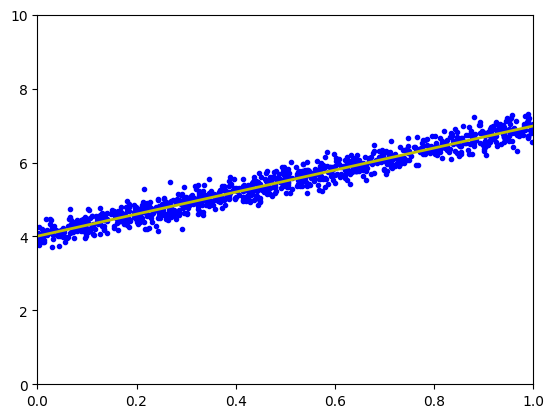

In [ ]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
np.random.seed(2)

X = np.random.rand(1000, 1)
y = 4 + 3 * X + .2*np.random.randn(1000, 1) # noise added

# Building Xbar
one = np.ones((X.shape[0],1))
Xbar = np.concatenate((one, X), axis = 1)

A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w_lr = np.dot(np.linalg.pinv(A), b)
print('Solution found by formula: w = ',w_lr.T)


# Display result
w = w_lr
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(0, 1, 2, endpoint=True)
y0 = w_0 + w_1*x0

# Draw the fitting line
plt.plot(X.T, y.T, 'b.')     # data
plt.plot(x0, y0, 'y', linewidth = 2)   # the fitting line
plt.axis([0, 1, 0, 10])
plt.show()




kiểm tra đạo hàm

Việc tính đạo hàm của hàm nhiều biến thông thường khá phức tạp và rất dễ mắc lỗi, nếu chúng ta tính sai đạo hàm thì thuật toán GD không thể chạy đúng được. Trong thực nghiệm, có một cách để kiểm tra liệu đạo hàm tính được có chính xác không. Cách này dựa trên định nghĩa của đạo hàm (cho hàm 1 biến): f′(x)=limε→o(f(x+ε)−f(x))/ε

Một cách thường được sử dụng là lấy một giá trị ε rất nhỏ, ví dụ 10−6, và sử dụng công thức: f′(x)≈(f(x+ε)−f(x−ε))/2ε    (2)

Cách tính này được gọi là numerical gradient.

In [ ]:
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
np.random.seed(2)

X = np.random.rand(1000, 1)
y = 4 + 3 * X + .2*np.random.randn(1000, 1) # noise added

# Building Xbar
one = np.ones((X.shape[0],1))
Xbar = np.concatenate((one, X), axis = 1)

def grad(w):
    N = Xbar.shape[0]
    return 1/N * Xbar.T.dot(Xbar.dot(w) - y)

def cost(w):
    N = Xbar.shape[0]
    return .5/N*np.linalg.norm(y - Xbar.dot(w), 2)**2;

def numerical_grad(w, cost):
    eps = 1e-4
    g = np.zeros_like(w)
    for i in range(len(w)):
        w_p = w.copy()
        w_n = w.copy()
        w_p[i] += eps
        w_n[i] -= eps
        g[i] = (cost(w_p) - cost(w_n))/(2*eps)
    return g

def check_grad(w, cost, grad):
    w = np.random.rand(w.shape[0], w.shape[1])
    grad1 = grad(w)
    grad2 = numerical_grad(w, cost)
    return True if np.linalg.norm(grad1 - grad2) < 1e-6 else False

print( 'Checking gradient...', check_grad(np.random.rand(2, 1), cost, grad))

Checking gradient... True


Cách 2: sử dụng gradient descent
Giả sử ta cần tìm global minimum cho hàm f(θ) trong đó θ (theta) là một vector, thường được dùng để ký hiệu tập hợp các tham số của một mô hình cần tối ưu (trong Linear Regression thì các tham số chính là hệ số w). Đạo hàm của hàm số đó tại một điểm θ bất kỳ được ký hiệu là ∇θf(θ) (hình tam giác ngược đọc là nabla). Tương tự như hàm 1 biến, thuật toán GD cho hàm nhiều biến cũng bắt đầu bằng một điểm dự đoán θ0, sau đó, ở vòng lặp thứ t, quy tắc cập nhật là:

θt+1=θt−η∇θf(θt)

Hoặc viết dưới dạng đơn giản hơn: θ=θ−η∇θf(θ).

Quy tắc cần nhớ: luôn luôn đi ngược hướng với đạo hàm

In [ ]:
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
np.random.seed(2)

X = np.random.rand(1000, 1)
y = 4 + 3 * X + .2*np.random.randn(1000, 1) # noise added
# Building Xbar
one = np.ones((X.shape[0],1))
Xbar = np.concatenate((one, X), axis = 1)

def grad(w):
    N = Xbar.shape[0]
    return 1/N * Xbar.T.dot(Xbar.dot(w) - y)

def cost(w):
    N = Xbar.shape[0]
    return .5/N*np.linalg.norm(y - Xbar.dot(w), 2)**2;

def myGD(w_init, grad, eta):
    w = [w_init]
    for it in range(100):
        w_new = w[-1] - eta*grad(w[-1])
        if np.linalg.norm(grad(w_new))/len(w_new) < 1e-3:
            break
        w.append(w_new)
    return (w, it)

w_init = np.array([[2], [1]])
(w1, it1) = myGD(w_init, grad, 1)
print('Solution found by GD: w = ', w1[-1].T, ',\nafter %d iterations.' %(it1+1))

Solution found by GD: w =  [[4.02199496 2.95380036]] ,
after 50 iterations.


Gradient Descent với Momentum

v
t
​
 =γv
t−1
​
 +η∇
θ
​
 J(θ)

 θ=θ−v
t
​

Chúng ta xem xét một hàm đơn giản có hai điểm local minimum, trong đó 1 điểm là global minimum:

 f(x)=x^
2
 +10sin(x)

Đạo hàm (gradient): f
′
 (x)=2x+10cos(x)




In [ ]:
import numpy as np

def cost(theta):
    return theta**2 + 10 * np.sin(theta)

def grad(theta):
    return 2 * theta + 10 * np.cos(theta)
# check convergence
def has_converged(theta_new, grad):
    return np.linalg.norm(grad(theta_new))/len(theta_new) < 1e-3

def GD_momentum(theta_init, grad, eta, gamma):
    # Suppose we want to store history of theta
    theta = [theta_init]
    v_old = np.zeros_like(theta_init)
    for it in range(100):
        v_new = gamma*v_old + eta*grad(theta[-1])
        theta_new = theta[-1] - v_new
        if has_converged(theta_new, grad):
            break
        theta.append(theta_new)
        v_old = v_new
    return theta
theta_init = np.array([1.0, 2.0, -1.5])
eta = 0.1
gamma = 0.9
result=GD_momentum(theta_init, grad, eta, gamma)
print(f"Solution of GD is {result[-1]} after {len(result)-1} iterations")

Solution of GD is [-1.30556474  3.84069822 -1.30645857] after 100 iterations


Nesterov accelerated gradient (NAG)

v
t
​
 =γv
t−1
​
 +η∇
θ
​
 J(θ−γv
t−1
​
 )

 θ=θ−v
t
​



In [ ]:
import numpy as np

def cost(theta):

    return theta**2 + 10 * np.sin(theta)

def grad(theta):

    return 2 * theta + 10 * np.cos(theta)


def has_converged(theta_new, grad):

    return np.linalg.norm(grad(theta_new)) / len(theta_new) < 1e-3

def GD_NAG(theta_init, grad, eta, gamma):
    theta = [theta_init]
    v_old = np.zeros_like(theta_init)
    for it in range(100):
        v_new = gamma * v_old + eta * grad(theta[-1] - gamma * v_old)
        theta_new = theta[-1] - v_new
        theta.append(theta_new)
        if has_converged(theta_new, grad):
            break

        v_old = v_new
    return theta
theta_init = np.array([1.0, 2.0, -1.5])
eta = 0.1
gamma = 0.9
result=GD_NAG(theta_init, grad, eta, gamma)
print(f"Solution of GD is {result[-1]} after {len(result)-1} iterations")

Solution of GD is [-1.30625983  3.8374445  -1.30637933] after 13 iterations
